# Aula 02: pipeline de experimento A/B

Este notebook acompanha a aula de causalidade. O objetivo não é fazer inferência estatística formal ainda. A ideia é entender, com tabelas e gráficos, como uma pergunta causal vira uma comparação entre tratamento e controle.

## 1. Pergunta causal

**Enviar um lembrete dois dias antes do prazo aumenta a chance de estudantes entregarem uma lista no prazo?**

- Unidade observacional: estudante.
- Tratamento: receber lembrete.
- Controle: não receber lembrete extra.
- Resultado: entregar a lista no prazo.
- Comparacao: taxa de entrega no grupo tratado contra taxa de entrega no grupo controle.

## 2. Por que precisamos de controle?

Se apenas observarmos quem recebeu lembrete e quem entregou, podemos confundir o efeito do lembrete com outras diferenças entre estudantes. Por exemplo, estudantes mais organizados poderiam abrir mais mensagens e também entregar mais no prazo.

A randomização ajuda a criar dois grupos comparáveis antes do tratamento.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)
n = 160

dados = pd.DataFrame({
    "estudante": np.arange(1, n + 1),
    "periodo": rng.choice([1, 2, 3, 4, 5], size=n, p=[0.25, 0.25, 0.20, 0.18, 0.12]),
    "listas_anteriores_no_prazo": rng.binomial(4, 0.62, size=n),
    "creditos_semestre": rng.choice([12, 16, 20, 24, 28], size=n, p=[0.10, 0.25, 0.35, 0.20, 0.10])
})

dados["grupo"] = rng.choice(["controle", "lembrete"], size=n)
dados.head()

,estudante,periodo,listas_anteriores_no_prazo,creditos_semestre,grupo
0,1,4,4,28,controle
1,2,2,1,20,controle
2,3,4,3,16,lembrete
3,4,3,4,20,controle
4,5,1,2,24,lembrete


::: {.callout-note title="Interpretação"}
Sem um grupo de controle, uma melhora posterior pode ser confundida com sazonalidade, aprendizado ou mudanças externas. O controle fornece a referência contrafactual do experimento.
:::

## 3. Os grupos parecem comparáveis?

Randomizacao não cria grupos idênticos. Ela cria grupos sem uma regra enviesada de escolha. Mesmo assim, vale olhar se as covariáveis observadas parecem parecidas.

In [2]:
resumo_grupos = dados.groupby("grupo")[[
    "periodo",
    "listas_anteriores_no_prazo",
    "creditos_semestre"
]].mean()

resumo_grupos.round(2)

,periodo,listas_anteriores_no_prazo,creditos_semestre
grupo,,,
controle,2.49,2.61,19.59
lembrete,2.67,2.52,20.49


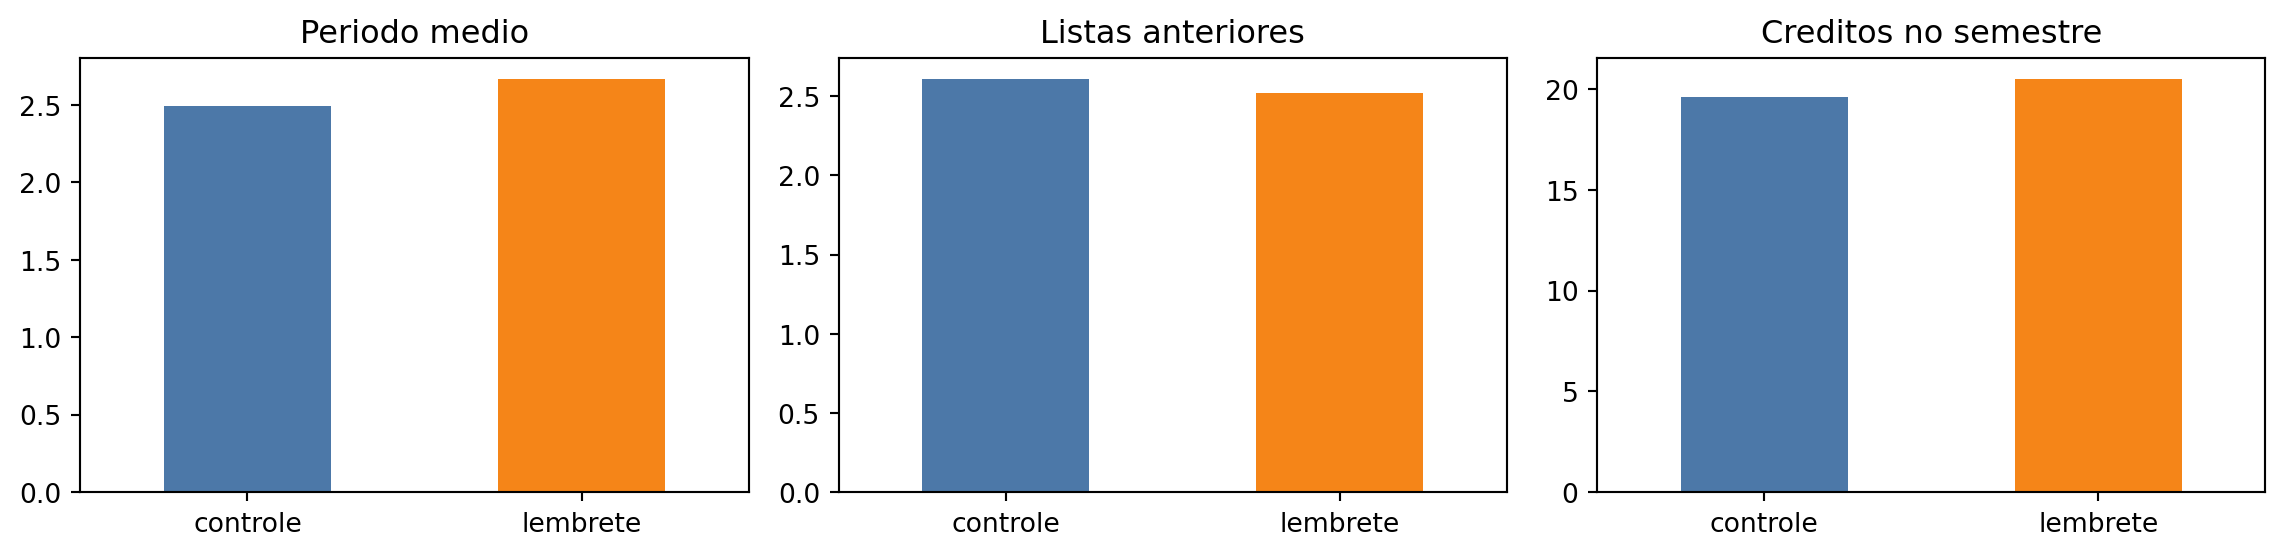

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3))

for ax, coluna, titulo in zip(
    axes,
    ["periodo", "listas_anteriores_no_prazo", "creditos_semestre"],
    ["Periodo medio", "Listas anteriores", "Creditos no semestre"]
):
    resumo_grupos[coluna].plot(kind="bar", ax=ax, color=["#4c78a8", "#f58518"])
    ax.set_title(titulo)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=0)

plt.tight_layout()

::: {.callout-note title="Interpretação"}
Diferenças pequenas antes do tratamento são compatíveis com a aleatorização. Desequilíbrios grandes sugeririam falha na atribuição, amostra pequena ou necessidade de investigar a coleta.
:::

## 4. Observando o resultado

Agora observamos quem entregou no prazo. Em um experimento real, esta coluna viria depois da intervenção. Aqui ela é simulada para fins didáticos.

In [4]:
base = 0.45
efeito_lembrete = 0.14
bonus_historico = 0.07 * dados["listas_anteriores_no_prazo"]
penalidade_carga = 0.006 * (dados["creditos_semestre"] - 20)

prob_entrega = (
    base
    + efeito_lembrete * (dados["grupo"] == "lembrete")
    + bonus_historico
    - penalidade_carga
).clip(0.05, 0.95)

dados["entregou_no_prazo"] = rng.binomial(1, prob_entrega)
dados[["estudante", "grupo", "entregou_no_prazo"]].head()

,estudante,grupo,entregou_no_prazo
0,1,controle,1
1,2,controle,1
2,3,lembrete,0
3,4,controle,1
4,5,lembrete,1


::: {.callout-note title="Interpretação"}
A diferença observada descreve esta amostra. Para atribuí-la ao tratamento, ainda precisamos considerar a variabilidade produzida pela atribuição aleatória.
:::

## 5. Comparando tratamento e controle

A primeira comparação é a taxa de entrega no prazo em cada grupo.

In [5]:
taxas = dados.groupby("grupo")["entregou_no_prazo"].mean().sort_index()
diferenca = taxas["lembrete"] - taxas["controle"]

pd.DataFrame({
    "taxa_entrega_no_prazo": taxas,
    "percentual": taxas * 100
}).round(1)

,taxa_entrega_no_prazo,percentual
grupo,,
controle,0.6,57.0
lembrete,0.8,76.5


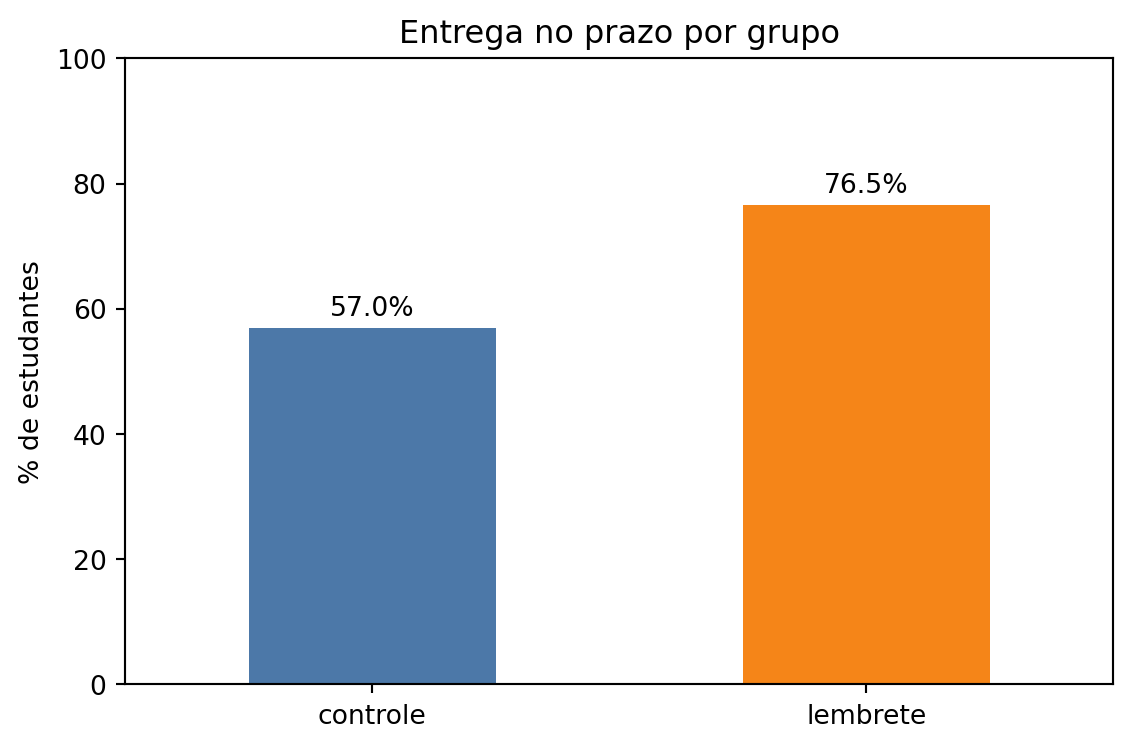

In [6]:
ax = (taxas * 100).plot(
    kind="bar",
    color=["#4c78a8", "#f58518"],
    figsize=(6, 4),
    ylim=(0, 100),
    title="Entrega no prazo por grupo"
)
ax.set_ylabel("% de estudantes")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=0)

for i, valor in enumerate(taxas * 100):
    ax.text(i, valor + 2, f"{valor:.1f}%", ha="center")

plt.tight_layout()

## 6. A diferenca observada

A diferença de taxas é uma forma simples de resumir o resultado. Ela mede quantos pontos percentuais separam o grupo tratado do grupo controle.

In [7]:
print(f"Diferenca observada: {100 * diferenca:.1f} pontos percentuais")

Diferenca observada: 19.6 pontos percentuais


## 7. Interpretacao causal

Como o grupo foi sorteado, a comparação entre tratamento e controle é mais justa do que uma comparação entre pessoas que escolheram receber ou não receber lembrete.

Mesmo assim, a conclusão deve ser cuidadosa: neste exemplo, observamos uma diferença positiva associada ao lembrete. Para afirmar um efeito em uma turma real, precisamos olhar o desenho do experimento, possíveis problemas de implementação e se houve vazamento entre grupos.

## 8. O que poderia dar errado?

- Alguns estudantes do controle podem receber o lembrete por colegas.
- O Moodle pode não éntregar todas as mensagens.
- Entregar no prazo não mede aprendizagem diretamente.
- O efeito pode ser diferente em outra turma ou outro tipo de lista.
- A intervenção pode ajudar pouco se o problema principal for dificuldade com o conteudo.

## Para praticar

1. Identifique tratamento, controle, resultado e unidade observacional.
2. Explique por que sortear estudantes ajuda na interpretacao causal.
3. Mude `efeito_lembrete` e observe como o gráfico muda.
4. Escreva uma limitacao que não aparece na lista acima.

# Guia teórico da Aula 02

## Resultados potenciais e ATE

Para cada unidade $i$, imagine dois resultados potenciais: $Y_i(1)$ sob tratamento e $Y_i(0)$ sob controle. O efeito individual seria $Y_i(1)-Y_i(0)$, mas observamos apenas um desses resultados. Esse é o problema fundamental da inferência causal.

O **ATE — Average Treatment Effect** é

$$\operatorname{ATE}=\mathbb E[Y(1)-Y(0)].$$

Como o contrafactual individual não é observado, precisamos de um grupo de comparação que represente o que teria acontecido sem a intervenção.

## Por que randomizar?

A randomização torna o tratamento independente, em expectativa, das características prévias. Assim, diferenças sistemáticas entre grupos podem ser atribuídas ao tratamento, sujeitas ao acaso, adesão, attrition e interferência. Controle, randomização e replicação cumprem papéis diferentes: comparação, balanceamento e mensuração da variabilidade.

## Estudos observacionais e confusão

Em estudos observacionais, uma variável $Z$ pode influenciar tratamento e resultado, criando uma associação não causal. Ajustar exige medir confundidores relevantes e justificar as suposições; nenhum algoritmo recupera uma variável importante que nunca foi observada.

Validade interna pergunta se a comparação identifica o efeito no estudo. Validade externa pergunta para quem, onde e quando o efeito pode ser transportado. Evidência forte exige desenho, mensuração, análise e transparência — não apenas um valor-p pequeno.
